# Real Estate Valuation - Linear and Logistic Regression

This notebook applies linear and logistic regression to the real estate valuation dataset, following the CRISP-DM process.

# 1. Business Understanding

The goal is to use the real estate dataset to understand and predict house prices.

We are doing two slightly different things:

- **Linear regression** is used to predict the actual house price per unit area.
- **Logistic regression** is used to predict whether the house price is above or below the average price.

The main idea is to see how things like the distance to the MRT station, number of convenience stores, house age and location are related to the price.

This is mainly an exercise with regression models, so we are not trying to build some perfect real estate price calculator.

# 2. Data Understanding

The dataset is the Real Estate Valuation dataset from the UCI Machine Learning Repository. It contains information about properties in Sindian District, New Taipei City, Taiwan.

The variables we are interested in are:

- transaction date
- house age
- distance to the nearest MRT station
- number of convenience stores
- latitude
- longitude

The target is the house price per unit area.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Load the dataset
real_estate_valuation = fetch_ucirepo(id=477)

X = real_estate_valuation.data.features.copy()
y = real_estate_valuation.data.targets.copy()

display(X.head())
display(y.head())

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245


,Y house price of unit area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1


### Basic information

First we just check what is actually in the dataset. This part is useful for making the model because without this we would not really know what the data looks like.

In [2]:
print("Features:")
display(X.info())

print("\nTarget:")
display(y.info())

print("\nMissing values in features:")
display(X.isnull().sum())

print("\nMissing values in target:")
display(y.isnull().sum())

print("\nFeature statistics:")
display(X.describe())

print("\nTarget statistics:")
display(y.describe())

Features:
<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


None


Target:
<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 1 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Y house price of unit area  414 non-null    float64
dtypes: float64(1)
memory usage: 3.4 KB


None


Missing values in features:


...

Y house price of unit area    0
dtype: int64


Feature statistics:


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270



Target statistics:


,Y house price of unit area
count,414.000000
mean,37.980193
std,13.606488
min,7.600000
25%,27.700000
50%,38.450000
75%,46.600000
max,117.500000


### Looking at the variables

A few quick plots are useful here. They don't prove anything by themselves, but they give us an idea about which variables might be useful for predicting price.

The variables related to location and the MRT seem especially worth checking.

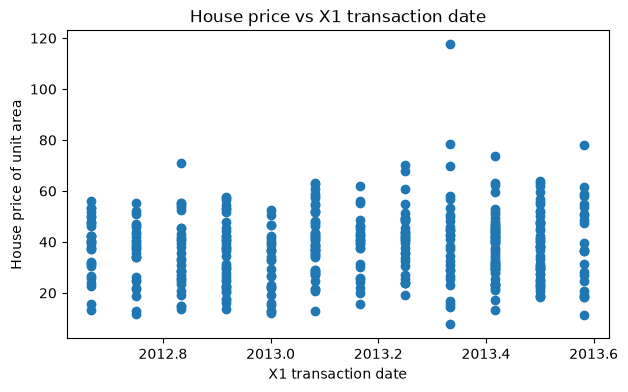

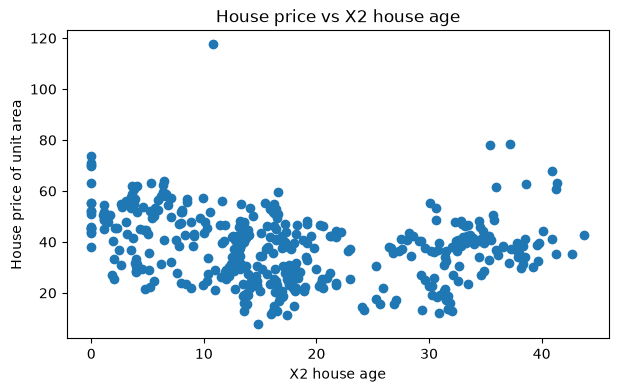

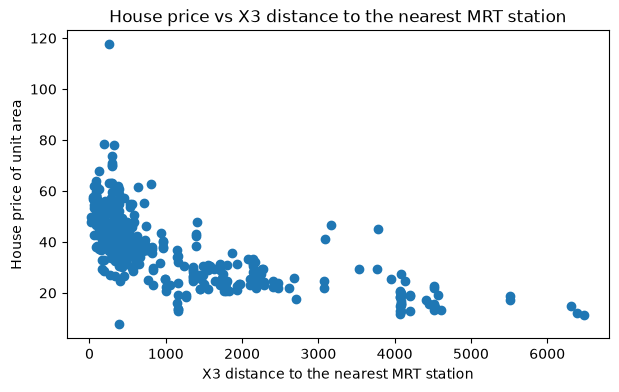

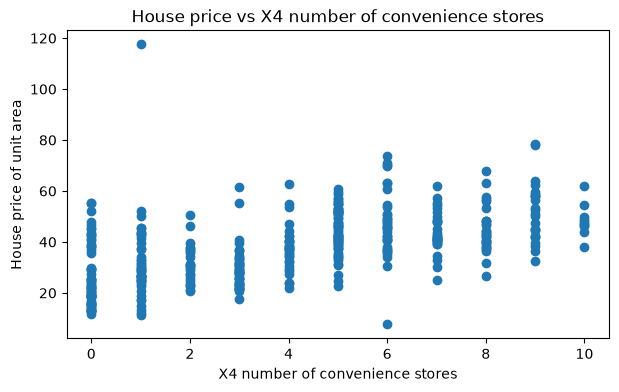

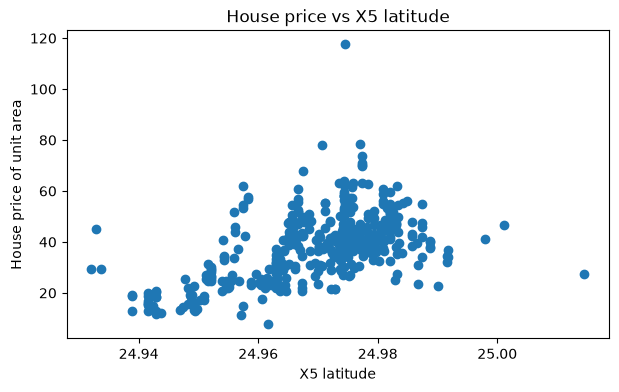

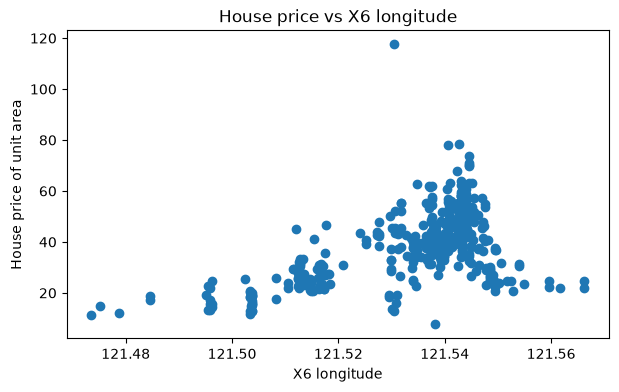

In [3]:
target = y.iloc[:, 0]

for column in X.columns:
    plt.figure(figsize=(7, 4))
    plt.scatter(X[column], target)
    plt.xlabel(column)
    plt.ylabel("House price of unit area")
    plt.title(f"House price vs {column}")
    plt.show()

### Quick observations

From the plots, the relationship is not perfectly straight for most variables. That is pretty normal with house prices.

Distance to the MRT, number of convenience stores and the location variables seem to have some visible relationship with the price. Transaction date and house age look less straightforward.

So we will test the variables with actual models instead of deciding based only on the graphs.

# 3. Data Preparation

There is not much missing data to deal with, which makes this part pretty easy.

We also clean the column names because the original names contain things like `X1`, `X2`, etc. Those don't really add anything.

In [4]:
# Make the column names easier to use
X.columns = [col.split(" ", 1)[1] if " " in col else col for col in X.columns]

print(X.columns.tolist())

['transaction date', 'house age', 'distance to the nearest MRT station', 'number of convenience stores', 'latitude', 'longitude']


### Train and test split

We use 75% of the data for training and 25% for testing.

The random state is fixed so that the same split is used every time. Otherwise the results can change every time the notebook is run.

In [5]:
test_size = 0.25
random_state = 123

X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=test_size,
    random_state=random_state
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 310
Testing rows: 104


### Preparing the logistic regression target

Linear regression can predict the actual price, but logistic regression needs categories.

So we make two categories using the **training-set average price**:

- `0` = price is below the average
- `1` = price is at or above the average

Using the training average avoids using the test data to define the target.

In [6]:
mean_price_train = y_train.mean()

y_train_log = (y_train >= mean_price_train).astype(int)
y_test_log = (y_test >= mean_price_train).astype(int)

print("Training average price:", round(mean_price_train, 2))
print("Class counts in training data:")
display(y_train_log.value_counts().sort_index())

Training average price: 38.06
Class counts in training data:


Y house price of unit area
0    152
1    158
Name: count, dtype: int64

### Scaling

For logistic regression, the variables have very different numerical ranges. MRT distance can be much larger than the number of convenience stores, for example.

So we standardize the features. The scaler is fitted only using the training data.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled, columns=X.columns, index=X_test.index
)

# 4. Modeling

Now we actually train the models.

We use both versions of the analysis:

1. A multiple linear regression using all variables.
2. Separate linear regressions using the four variables that looked more interesting.
3. A logistic regression using all variables.
4. A logistic regression using only MRT distance, so we can compare a simple model with the full model.

## 4.1 Linear regression using all features

This is the main linear regression model. It gets all six variables and tries to predict the actual house price.

In [8]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print(f"MAE:  {mae_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R²:   {r2_linear:.4f}")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

display(coefficients)

MAE:  5.14
RMSE: 7.33
R²:   0.6791


,Feature,Coefficient
0,transaction date,4.931155
1,house age,-0.270138
2,distance to the nearest MRT station,-0.004746
3,number of convenience stores,1.070986
4,latitude,224.139491
5,longitude,-30.321979


The coefficients show the direction of the relationship while keeping the other variables in the model.

I wouldn't read too much into the coefficients alone, because the variables are on different scales. The main thing here is how well the model predicts the test data.

## 4.2 Linear regression with individual variables

We test each variable on its own using MRT distance, number of convenience stores, latitude and longitude.

In [9]:
selected_features = [
    "distance to the nearest MRT station",
    "number of convenience stores",
    "latitude",
    "longitude"
]

single_results = []

for feature in selected_features:
    X_single = X[[feature]]

    X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
        X_single,
        target,
        test_size=test_size,
        random_state=random_state
    )

    model = LinearRegression()
    model.fit(X_train_single, y_train_single)

    pred = model.predict(X_test_single)

    single_results.append({
        "Feature": feature,
        "MAE": mean_absolute_error(y_test_single, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_single, pred)),
        "R²": r2_score(y_test_single, pred),
        "Coefficient": model.coef_[0]
    })

single_results_df = pd.DataFrame(single_results)
display(single_results_df.round(4))

,Feature,MAE,RMSE,R²,Coefficient
0,distance to the nearest MRT station,6.4148,8.8154,0.5365,-0.0071
1,number of convenience stores,8.1133,9.6760,0.4416,2.5571
2,latitude,7.6026,9.9482,0.4097,574.2858
3,longitude,8.0254,10.5552,0.3355,451.9352


These models are obviously simpler because they only know one thing about the property.

The point is mostly to compare the variables. A variable doing well on its own does not mean that it is the only thing affecting the price.

## 4.3 Logistic regression using all features

Now we switch to the classification problem.

The model predicts whether the house price is below or above the training-set average.

In [10]:
logistic_model_all = LogisticRegression(max_iter=1000)
logistic_model_all.fit(X_train_scaled, y_train_log)

y_pred_log_all = logistic_model_all.predict(X_test_scaled)

accuracy_all = accuracy_score(y_test_log, y_pred_log_all)
precision_all = precision_score(y_test_log, y_pred_log_all)
recall_all = recall_score(y_test_log, y_pred_log_all)

print(f"Accuracy:  {accuracy_all:.4f}")
print(f"Precision: {precision_all:.4f}")
print(f"Recall:    {recall_all:.4f}")

Accuracy:  0.8077
Precision: 0.8214
Recall:    0.8214


### Feature importance for logistic regression

Permutation importance gives us a rough idea of which variables are useful for the classification model.

It works by shuffling one feature and checking how much the model performance gets worse. If performance drops a lot, the feature was probably useful.

,Feature,Importance
2,distance to the nearest MRT station,0.1288
4,latitude,0.0423
1,house age,0.0173
0,transaction date,-0.0019
3,number of convenience stores,-0.0029
5,longitude,-0.0154


/var/folders/wv/6d453psx4ks3q_hd1g1sn8zm0000gn/T/ipykernel_52352/2924139236.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(importance.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])


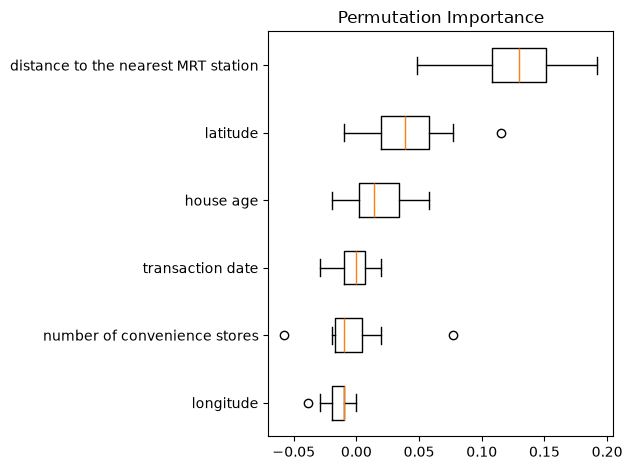

In [20]:
importance = permutation_importance(logistic_model_all,X_test_scaled,y_test_log,n_repeats=10,random_state=123,scoring="accuracy")
sorted_idx = importance.importances_mean.argsort()

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df.round(4))

plt.show()
fig, ax = plt.subplots()
ax.boxplot(importance.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

## 4.4 Logistic regression using only MRT distance

This is useful because we can compare a model with all the variables against a very simple model with only one variable.

In [12]:
mrt_feature = "distance to the nearest MRT station"

X_train_mrt = X_train[[mrt_feature]]
X_test_mrt = X_test[[mrt_feature]]

mrt_scaler = StandardScaler()
X_train_mrt_scaled = mrt_scaler.fit_transform(X_train_mrt)
X_test_mrt_scaled = mrt_scaler.transform(X_test_mrt)

logistic_model_mrt = LogisticRegression(max_iter=1000)
logistic_model_mrt.fit(X_train_mrt_scaled, y_train_log)

y_pred_log_mrt = logistic_model_mrt.predict(X_test_mrt_scaled)

accuracy_mrt = accuracy_score(y_test_log, y_pred_log_mrt)
precision_mrt = precision_score(y_test_log, y_pred_log_mrt)
recall_mrt = recall_score(y_test_log, y_pred_log_mrt)

print(f"Accuracy:  {accuracy_mrt:.4f}")
print(f"Precision: {precision_mrt:.4f}")
print(f"Recall:    {recall_mrt:.4f}")

Accuracy:  0.8365
Precision: 0.7910
Recall:    0.9464


# 5. Evaluation

Now we compare the results.

For linear regression:

- **MAE** tells the average size of the prediction error.
- **RMSE** also measures error, but gives bigger errors more weight.
- **R²** gives an idea of how much of the variation in price the model explains.

For logistic regression:

- **Accuracy** = how many predictions were correct.
- **Precision** = how often predicted positive cases were actually positive.
- **Recall** = how many of the actual positive cases were found.

## 5.1 Linear regression results

In [13]:
linear_comparison = pd.DataFrame({
    "Model": ["All features"] + selected_features,
    "MAE": [mae_linear] + single_results_df["MAE"].tolist(),
    "RMSE": [rmse_linear] + single_results_df["RMSE"].tolist(),
    "R²": [r2_linear] + single_results_df["R²"].tolist()
})

display(linear_comparison.round(4))

,Model,MAE,RMSE,R²
0,All features,5.1420,7.3347,0.6791
1,distance to the nearest MRT station,6.4148,8.8154,0.5365
2,number of convenience stores,8.1133,9.6760,0.4416
3,latitude,7.6026,9.9482,0.4097
4,longitude,8.0254,10.5552,0.3355


The full model uses more information, so it is a more complete way of predicting the price. The single-variable models are mainly useful for seeing what happens when we only give the model one feature.

There is also no reason to expect one variable to explain everything about a house price. Location, age, transport and nearby services can all matter at the same time.

## 5.2 Residual plot

A residual is basically the real price minus the predicted price.

We want the residuals to be reasonably spread around zero without some obvious pattern.

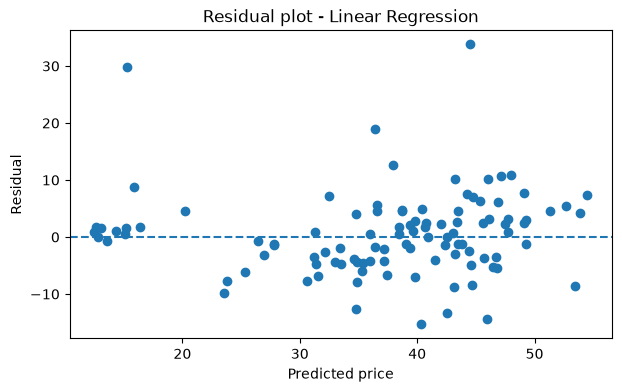

In [14]:
residuals = y_test - y_pred_linear

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_linear, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Residual")
plt.title("Residual plot - Linear Regression")
plt.show()

## 5.3 Logistic regression results

Here is the direct comparison between the full logistic model and the MRT-only model.

In [15]:
logistic_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "All features": [accuracy_all, precision_all, recall_all],
    "MRT only": [accuracy_mrt, precision_mrt, recall_mrt]
})

display(logistic_comparison.round(4))

,Metric,All features,MRT only
0,Accuracy,0.8077,0.8365
1,Precision,0.8214,0.7910
2,Recall,0.8214,0.9464


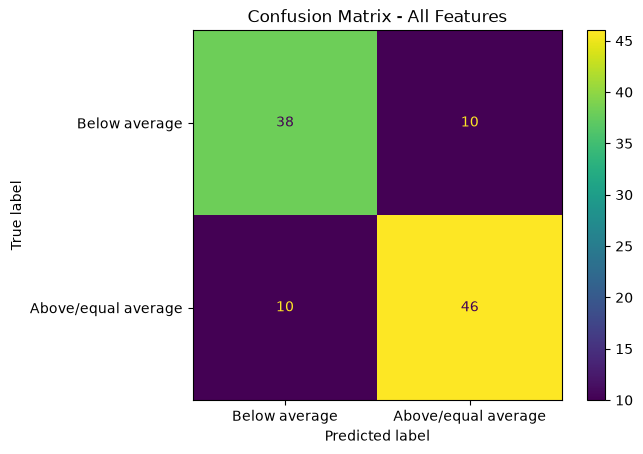

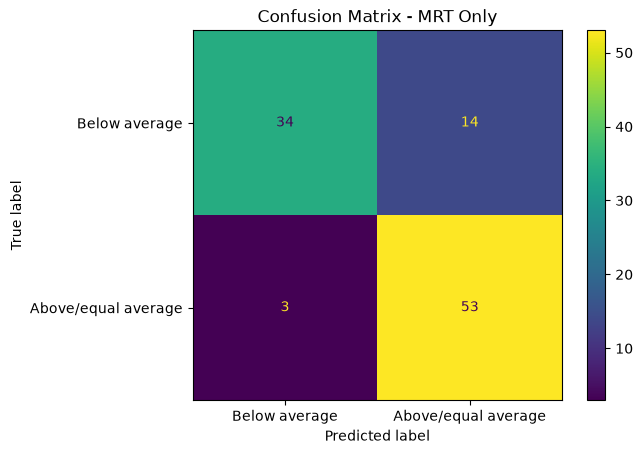

In [16]:
# Confusion matrix - all features
cm_all = confusion_matrix(y_test_log, y_pred_log_all)

ConfusionMatrixDisplay(
    confusion_matrix=cm_all,
    display_labels=["Below average", "Above/equal average"]
).plot()

plt.title("Confusion Matrix - All Features")
plt.show()

# Confusion matrix - MRT only
cm_mrt = confusion_matrix(y_test_log, y_pred_log_mrt)

ConfusionMatrixDisplay(
    confusion_matrix=cm_mrt,
    display_labels=["Below average", "Above/equal average"]
).plot()

plt.title("Confusion Matrix - MRT Only")
plt.show()

### Evaluation summary

The models give a useful comparison between using all the variables and using only one variable.

The linear model predicts the actual price, while the logistic model simplifies the problem into two groups. This means their results should not be directly compared with each other, because they are doing different jobs.

The MRT-only model is also useful as a simple baseline. If it performs noticeably worse than the full model, that shows that the other variables add useful information.

# 6. Deployment

If this was an actual application, the linear regression model could be used to give a rough predicted price for a new property.

The logistic model could instead answer a simpler question: does the predicted property belong to the lower or higher price group?

In a real system, the model would need to be retrained regularly because housing prices change over time. It would also be a good idea to get more data and test other models.

So basically, these models are useful for demonstrating the relationship in the dataset, but I would not use this notebook alone to decide whether to buy a house.

# Final conclusion

The main thing from this project is that regression can be used in two different ways with the same dataset.

Linear regression predicts a continuous price, while logistic regression turns the problem into two categories.

The full models use all the available variables, and the smaller models let us see what happens when we only use selected variables. The results show that location-related information and distance to the MRT are worth paying attention to.

There are still plenty of limitations, especially because the dataset is fairly small and only contains a limited number of variables. But for this assignment, the models give a decent example of the CRISP-DM process from understanding the problem all the way to evaluating and discussing the models.